# Notebook 2: Time Series Reconstruction & Carbon Intensity Signal

**Pipeline Stage 2** — From Spark Parquet to Multivariate Time Series

This notebook transforms the cleaned Parquet output from Notebook 1 into a **structured time series** suitable for statistical analysis and model training. Key operations:

1. **Wide Pivot**: Convert the "Long List" format (`machine_id × timestamp`) into a "Wide Matrix" (rows = timestamps, columns = per-machine metrics)
2. **Temporal Imputation**: Forward-fill (Last Observation Carried Forward) to close NaN gaps
3. **Synthetic Carbon Intensity**: Generate a realistic diurnal CI signal (modeled after a solar-heavy grid like California CAISO)
4. **Multivariate Join**: Align server metrics with the external CI signal on the timestamp index
5. **Feature Scaling**: Min-Max normalization to $[0,1]$ for gradient-based models

## 2.1 Setup & Load Parquet

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                        "pandas", "numpy", "pyarrow", "matplotlib", "seaborn", "scikit-learn"])

0

In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# ── paths ─────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
PARQUET_DIR = os.path.join(BASE_DIR, "data", "clean_parquet", "subset")
META_PATH   = os.path.join(BASE_DIR, "data", "selected_machines.json")
OUT_DIR     = os.path.join(BASE_DIR, "data")
FIG_DIR     = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Load machine list from Notebook 1
with open(META_PATH) as f:
    meta = json.load(f)
selected_machines = meta["selected_machines"]
print(f"Selected machines: {selected_machines}")

Selected machines: ['m_2251', 'm_1223', 'm_1565', 'm_1617', 'm_3060', 'm_34', 'm_1437', 'm_2544', 'm_1903', 'm_1672']


In [3]:
# Load parquet subset
df = pd.read_parquet(PARQUET_DIR)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print(f"Machines: {df['machine_id'].nunique()}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 21,234 rows × 9 columns
Machines: 10
Columns: ['ts_bucket', 'cpu_util_percent', 'mem_util_percent', 'mem_gps', 'mkpi', 'net_in', 'net_out', 'disk_io_percent', 'machine_id']


,ts_bucket,cpu_util_percent,mem_util_percent,mem_gps,mkpi,net_in,net_out,disk_io_percent,machine_id
0,900,25.666667,86.500000,NaN,NaN,33.34,24.20,2.000000,m_1223
1,1200,29.625000,88.875000,NaN,NaN,33.34,24.21,3.125000,m_1223
2,1500,27.500000,88.333333,NaN,NaN,33.35,24.21,1.833333,m_1223
3,1800,24.444444,86.888889,NaN,NaN,33.35,24.21,1.666667,m_1223
4,2100,23.000000,85.833333,NaN,NaN,33.35,24.21,1.500000,m_1223


## 2.2 Datetime Index Construction

Convert the epoch-offset `ts_bucket` into a proper `DatetimeIndex`. We anchor the trace to a synthetic start date of **2018-01-01** (consistent with the Alibaba v2018 trace period).

In [4]:
# Convert ts_bucket (seconds from dataset epoch) to datetime
EPOCH_ANCHOR = pd.Timestamp("2018-01-01")
df["datetime"] = EPOCH_ANCHOR + pd.to_timedelta(df["ts_bucket"], unit="s")

print(f"Time range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Duration  : {df['datetime'].max() - df['datetime'].min()}")
df.head()

Time range: 2018-01-01 00:00:00 → 2018-01-08 23:55:00
Duration  : 7 days 23:55:00


,ts_bucket,cpu_util_percent,mem_util_percent,mem_gps,mkpi,net_in,net_out,disk_io_percent,machine_id,datetime
0,900,25.666667,86.500000,NaN,NaN,33.34,24.20,2.000000,m_1223,2018-01-01 00:15:00
1,1200,29.625000,88.875000,NaN,NaN,33.34,24.21,3.125000,m_1223,2018-01-01 00:20:00
2,1500,27.500000,88.333333,NaN,NaN,33.35,24.21,1.833333,m_1223,2018-01-01 00:25:00
3,1800,24.444444,86.888889,NaN,NaN,33.35,24.21,1.666667,m_1223,2018-01-01 00:30:00
4,2100,23.000000,85.833333,NaN,NaN,33.35,24.21,1.500000,m_1223,2018-01-01 00:35:00


## 2.3 Wide Pivot (Long → Wide Matrix)

Transform from the **tall/long** format:

| datetime | machine_id | cpu_util_percent | ... |
|----------|-----------|-----------------|-----|
| 2018-01-01 00:00 | m_1 | 42.5 | ... |
| 2018-01-01 00:00 | m_2 | 31.0 | ... |

Into the **wide** format:

| datetime | cpu_m_1 | cpu_m_2 | mem_m_1 | mem_m_2 | ... |
|----------|---------|---------|---------|---------|-----|
| 2018-01-01 00:00 | 42.5 | 31.0 | 88.1 | 72.3 | ... |

In [5]:
METRIC_COLS = ["cpu_util_percent", "mem_util_percent", "net_in", "net_out", "disk_io_percent"]

pivot_frames = []
for metric in METRIC_COLS:
    piv = df.pivot_table(
        index="datetime",
        columns="machine_id",
        values=metric,
        aggfunc="mean"
    )
    # Rename columns: cpu_m_1932, mem_m_1932, etc.
    short = metric.replace("_util_percent", "").replace("_percent", "")
    piv.columns = [f"{short}_{mid}" for mid in piv.columns]
    pivot_frames.append(piv)

wide_df = pd.concat(pivot_frames, axis=1).sort_index()

# Also compute cluster-wide aggregates (mean across all selected machines)
for metric in METRIC_COLS:
    cols_for_metric = [c for c in wide_df.columns if c.startswith(metric.replace("_util_percent", "").replace("_percent", "") + "_")]
    short = metric.replace("_util_percent", "").replace("_percent", "")
    wide_df[f"{short}_cluster_avg"] = wide_df[cols_for_metric].mean(axis=1)

print(f"Wide matrix shape: {wide_df.shape}")
print(f"Time index: {wide_df.index.min()} → {wide_df.index.max()}")
print(f"Frequency check: {pd.infer_freq(wide_df.index[:50])}")
wide_df.head()

Wide matrix shape: (2241, 55)
Time index: 2018-01-01 00:00:00 → 2018-01-08 23:55:00
Frequency check: 5min


,cpu_m_1223,cpu_m_1437,cpu_m_1565,cpu_m_1617,cpu_m_1672,cpu_m_1903,cpu_m_2251,cpu_m_2544,cpu_m_3060,cpu_m_34,...,disk_io_m_1903,disk_io_m_2251,disk_io_m_2544,disk_io_m_3060,disk_io_m_34,cpu_cluster_avg,mem_cluster_avg,net_in_cluster_avg,net_out_cluster_avg,disk_io_cluster_avg
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,NaN,19.100000,8.736842,12.636364,38.250000,NaN,0.0,NaN,15.777778,15.400000,...,NaN,0.0,NaN,2.111111,3.700000,15.700141,73.957895,35.291266,29.127179,3.198238
2018-01-01 00:05:00,NaN,29.000000,21.166667,21.111111,53.000000,NaN,0.0,NaN,28.461538,20.900000,...,NaN,0.0,NaN,2.461538,3.300000,24.805617,76.313640,35.294288,29.129848,3.700105
2018-01-01 00:10:00,NaN,29.875000,22.000000,20.250000,52.444444,NaN,0.0,NaN,28.333333,24.461538,...,NaN,0.0,NaN,3.750000,6.384615,25.337759,75.642063,35.300397,29.136774,5.590263
2018-01-01 00:15:00,25.666667,30.636364,26.555556,20.111111,54.928571,NaN,0.0,NaN,35.571429,21.125000,...,NaN,0.0,NaN,2.714286,2.750000,26.824337,77.093975,35.058881,28.523148,3.666622
2018-01-01 00:20:00,29.625000,27.500000,22.714286,21.888889,53.111111,28.285714,0.0,NaN,29.750000,24.461538,...,5.142857,0.0,NaN,2.416667,2.615385,26.370726,79.584537,34.666914,27.911453,2.852547


## 2.4 Temporal Imputation (Forward Fill)

Handle the remaining NaN gaps using **Forward Fill** (Last Observation Carried Forward). This preserves the temporal continuity required by autoregressive and sequence models. We report gap statistics before and after imputation.

In [6]:

# ── STEP 1: Enforce a strict regular 5-minute DatetimeIndex via resample ──
# Without this, missing 5-min buckets create irregular gaps that silently corrupt
# STL decomposition, ADF tests, and SARIMAX (all require a gapless regular index).
wide_df = wide_df.resample('5min').mean()   # fills missing buckets with NaN
print(f"After resample — shape: {wide_df.shape}")
print(f"Frequency inferred: {pd.infer_freq(wide_df.index)}")

# ── STEP 2: Forward-fill then backward-fill to close the newly created gaps ──
null_before = wide_df.isnull().sum()
null_pct_before = (wide_df.isnull().sum() / len(wide_df) * 100)
print("\n── Null % before imputation (top 10) ──")
print(null_pct_before.sort_values(ascending=False).head(10).round(2))

# Forward fill, then backward fill for any leading NaNs
wide_df = wide_df.ffill().bfill()

# Verify
null_after = wide_df.isnull().sum().sum()
print(f"\nTotal NaN after imputation: {null_after}")
assert null_after == 0, "Still have NaN values!"


After resample — shape: (2304, 55)
Frequency inferred: 5min

── Null % before imputation (top 10) ──
cpu_m_1437        9.11
net_in_m_1437     9.11
mem_m_1437        9.11
disk_io_m_1437    9.11
net_out_m_1437    9.11
cpu_m_34          8.98
mem_m_34          8.98
net_in_m_34       8.98
net_out_m_34      8.98
disk_io_m_34      8.98
dtype: float64

Total NaN after imputation: 0


## 2.5 Synthetic Carbon Intensity Signal

We generate a **realistic diurnal carbon intensity** signal modeled after a solar-heavy electricity grid (similar to California CAISO):

- **Midday (10:00–16:00)**: Low CI ≈ 150–250 $gCO_2/kWh$ (high solar generation)
- **Evening peak (17:00–22:00)**: High CI ≈ 450–600 $gCO_2/kWh$ (gas peaker plants)
- **Night (22:00–06:00)**: Moderate CI ≈ 350–450 $gCO_2/kWh$
- **Gaussian noise** + slight weekly modulation (weekends have lower industrial demand)

This creates the **temporal variation** that the carbon-aware scheduler will exploit.

In [7]:
np.random.seed(42)

n_steps = len(wide_df)
timestamps = wide_df.index
hours = np.array(timestamps.hour + timestamps.minute / 60.0)
day_of_week = np.array(timestamps.dayofweek)  # 0=Mon, 6=Sun

# Base diurnal pattern: high at night/evening, low midday (solar effect)
# Use a combination of sinusoids to create asymmetric shape
diurnal = (
    400                                          # baseline
    - 180 * np.exp(-0.5 * ((hours - 13) / 3)**2)  # solar dip centered at 1 PM
    + 100 * np.exp(-0.5 * ((hours - 19) / 2)**2)  # evening ramp (gas peakers)
)

# Weekly modulation: weekends have ~10% lower CI (less industrial load)
weekly_mod = np.where(day_of_week >= 5, -40, 0)

# Add realistic noise (autocorrelated, not white)
noise = np.zeros(n_steps)
noise[0] = np.random.normal(0, 15)
for i in range(1, n_steps):
    noise[i] = 0.85 * noise[i-1] + np.random.normal(0, 15)

# Combine and clip to realistic range [100, 700]
carbon_intensity = np.clip(diurnal + weekly_mod + noise, 100, 700)

wide_df["carbon_intensity_gCO2_kWh"] = carbon_intensity

print(f"Carbon Intensity stats:")
print(f"  Mean: {carbon_intensity.mean():.1f} gCO₂/kWh")
print(f"  Std:  {carbon_intensity.std():.1f}")
print(f"  Min:  {carbon_intensity.min():.1f}")
print(f"  Max:  {carbon_intensity.max():.1f}")

Carbon Intensity stats:
  Mean: 357.7 gCO₂/kWh
  Std:  84.5
  Min:  116.1
  Max:  544.4


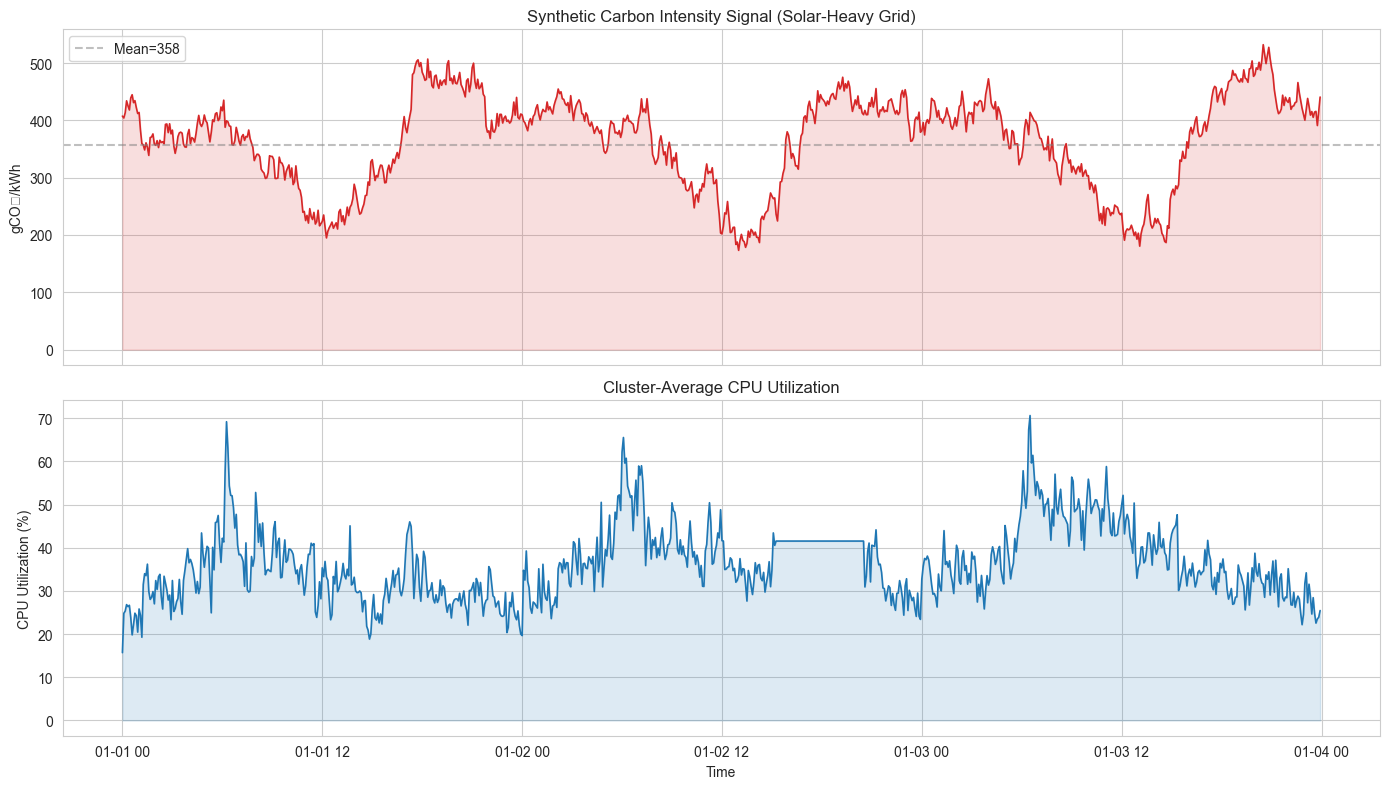

Saved → figures/ci_and_cpu_signal.png


In [8]:
# Visualize 3 days of the carbon intensity signal
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_slice = slice(0, 288*3)  # 3 days (288 steps/day at 5-min intervals)

# Carbon Intensity
axes[0].plot(wide_df.index[plot_slice], wide_df["carbon_intensity_gCO2_kWh"].iloc[plot_slice],
             color="#d62728", linewidth=1.2)
axes[0].fill_between(wide_df.index[plot_slice], wide_df["carbon_intensity_gCO2_kWh"].iloc[plot_slice],
                     alpha=0.15, color="#d62728")
axes[0].set_ylabel("gCO₂/kWh")
axes[0].set_title("Synthetic Carbon Intensity Signal (Solar-Heavy Grid)")
axes[0].axhline(y=carbon_intensity.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Mean={carbon_intensity.mean():.0f}')
axes[0].legend()

# Cluster CPU alongside
axes[1].plot(wide_df.index[plot_slice], wide_df["cpu_cluster_avg"].iloc[plot_slice],
             color="#1f77b4", linewidth=1.2)
axes[1].fill_between(wide_df.index[plot_slice], wide_df["cpu_cluster_avg"].iloc[plot_slice],
                     alpha=0.15, color="#1f77b4")
axes[1].set_ylabel("CPU Utilization (%)")
axes[1].set_title("Cluster-Average CPU Utilization")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ci_and_cpu_signal.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/ci_and_cpu_signal.png")


## 2.6 Feature Scaling (Min-Max Normalization)

Normalize all resource metrics to the $[0, 1]$ range using Min-Max scaling:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

The scaled file is saved as a **reference artifact**. Statistical models (SARIMAX, SETAR, MS-AR) in Notebook 4 operate on the original scale for interpretability. The LSTM model in Notebook 4 applies its own inline z-score normalization using only training-set statistics to avoid data leakage — which is the correct approach for time-series forecasting. We store the scaler parameters for inverse transformation if needed.


In [9]:
from sklearn.preprocessing import MinMaxScaler

# Columns to scale (all except the datetime index)
scale_cols = [c for c in wide_df.columns]  # all numeric columns

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(wide_df[scale_cols])

scaled_df = pd.DataFrame(
    scaled_values,
    index=wide_df.index,
    columns=scale_cols
)

# Save scaler parameters for inverse transform later
scaler_params = pd.DataFrame({
    "feature": scale_cols,
    "min": scaler.data_min_,
    "max": scaler.data_max_,
    "scale": scaler.scale_,
})
scaler_params.to_csv(os.path.join(OUT_DIR, "scaler_params.csv"), index=False)

print("Scaled data summary:")
print(scaled_df.describe().round(3))
print(f"\nScaler parameters saved to: data/scaler_params.csv")

Scaled data summary:
       cpu_m_1223  cpu_m_1437  cpu_m_1565  cpu_m_1617  cpu_m_1672  cpu_m_1903  \
count    2304.000    2304.000    2304.000    2304.000    2304.000    2304.000   
mean        0.304       0.375       0.342       0.346       0.563       0.424   
std         0.135       0.178       0.148       0.157       0.184       0.158   
min         0.000       0.000       0.000       0.000       0.000       0.000   
25%         0.210       0.244       0.231       0.225       0.430       0.308   
50%         0.284       0.345       0.326       0.316       0.554       0.408   
75%         0.383       0.501       0.426       0.444       0.700       0.521   
max         1.000       1.000       1.000       1.000       1.000       1.000   

       cpu_m_2251  cpu_m_2544  cpu_m_3060  cpu_m_34  ...  disk_io_m_2251  \
count    2304.000    2304.000    2304.000  2304.000  ...        2304.000   
mean        0.001       0.390       0.316     0.371  ...           0.001   
std         0.032    

## 2.7 Visualizations: Raw vs. Cleaned Time Series

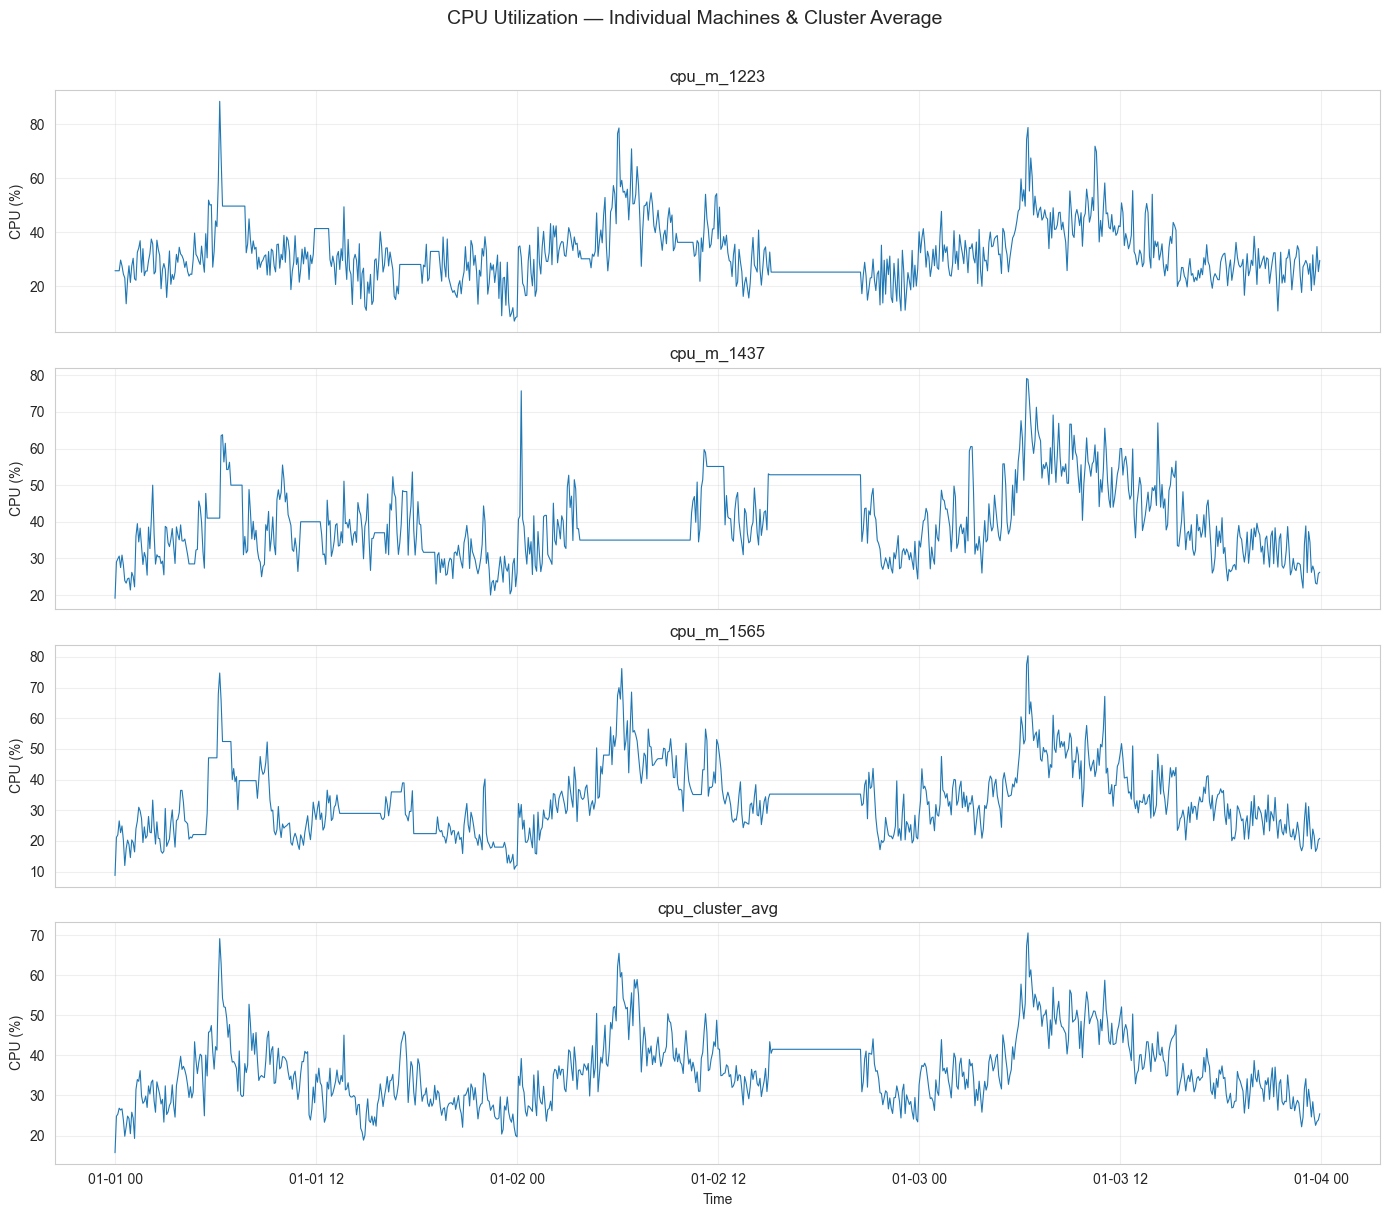

Saved → figures/cpu_timeseries_sample.png


In [10]:
# Plot CPU utilization for first 3 machines + cluster average (3 days)
cpu_cols = [c for c in wide_df.columns if c.startswith("cpu_") and "cluster" not in c][:3]
cpu_cols.append("cpu_cluster_avg")

fig, axes = plt.subplots(len(cpu_cols), 1, figsize=(14, 3*len(cpu_cols)), sharex=True)

for ax, col in zip(axes, cpu_cols):
    ax.plot(wide_df.index[plot_slice], wide_df[col].iloc[plot_slice], linewidth=0.8)
    ax.set_ylabel("CPU (%)")
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
fig.suptitle("CPU Utilization — Individual Machines & Cluster Average", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cpu_timeseries_sample.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/cpu_timeseries_sample.png")

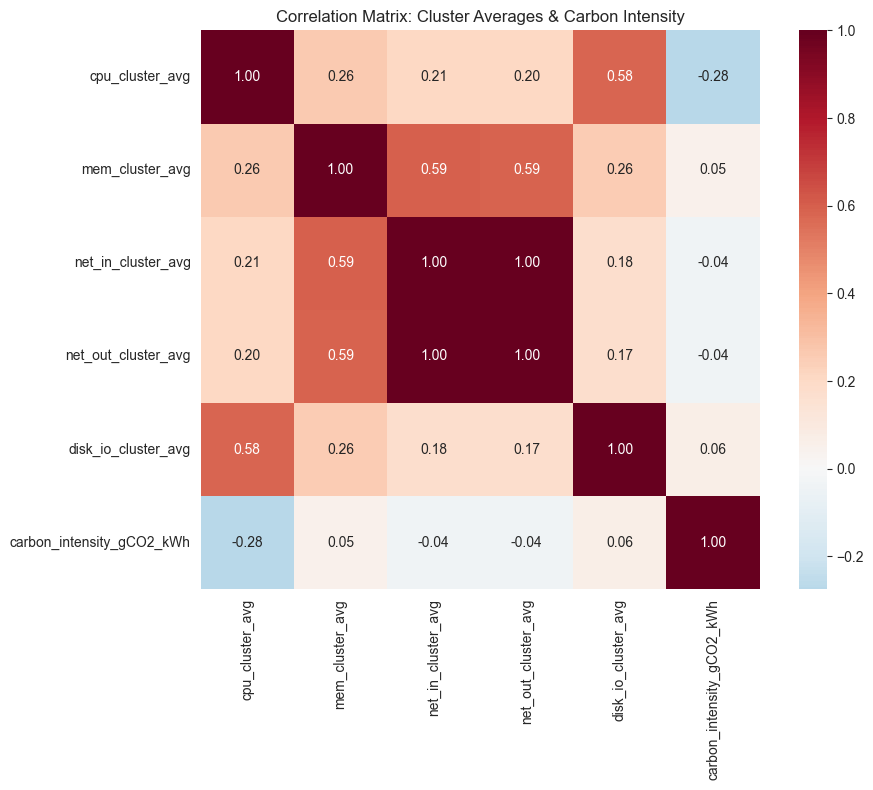

Saved → figures/correlation_heatmap.png


In [11]:
# Heatmap: correlation between all metrics for first 3 machines + CI
heatmap_cols = (
    [c for c in wide_df.columns if "cluster" in c]
    + ["carbon_intensity_gCO2_kWh"]
)
corr = wide_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax)
ax.set_title("Correlation Matrix: Cluster Averages & Carbon Intensity")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/correlation_heatmap.png")

## 2.8 Export Final Datasets

In [12]:
# Save UNSCALED data (for interpretable analysis in Notebook 3)
wide_df.to_parquet(os.path.join(OUT_DIR, "timeseries_ready.parquet"))
wide_df.to_csv(os.path.join(OUT_DIR, "timeseries_ready.csv"))

# Save SCALED data (for model training in Notebook 4)
scaled_df.to_parquet(os.path.join(OUT_DIR, "timeseries_scaled.parquet"))
scaled_df.to_csv(os.path.join(OUT_DIR, "timeseries_scaled.csv"))

print("Exports complete:")
print(f"  → data/timeseries_ready.parquet   ({wide_df.shape})  [unscaled]")
print(f"  → data/timeseries_ready.csv")
print(f"  → data/timeseries_scaled.parquet   ({scaled_df.shape})  [Min-Max 0–1]")
print(f"  → data/timeseries_scaled.csv")
print(f"  → data/scaler_params.csv")

Exports complete:
  → data/timeseries_ready.parquet   ((2304, 56))  [unscaled]
  → data/timeseries_ready.csv
  → data/timeseries_scaled.parquet   ((2304, 56))  [Min-Max 0–1]
  → data/timeseries_scaled.csv
  → data/scaler_params.csv


## 2.9 BDA Post-Processing — Spark MLlib Feature Correlation & Distributed Aggregation

After constructing the wide time-series matrix with pandas, we bring **Apache Spark** back to demonstrate BDA concepts *beyond* the initial ETL stage:

1. **Spark MLlib Correlation Matrix**: Compute pairwise Pearson correlations across all features using Spark's distributed linear algebra engine (`pyspark.ml.stat.Correlation`).
2. **Distributed Rolling Statistics**: Use Spark Window functions to compute rolling mean/std over all machines in parallel.
3. **Parquet Round-Trip**: Re-export the enriched dataset via Spark to demonstrate Spark-native write paths.

This proves that BDA is used **after preprocessing** — not just for ETL but for feature analysis and engineering.

In [13]:
# ── 2.9.1 Initialize Spark for Post-Processing BDA ──────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CarbonAware-BDA-PostProcessing")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print("Spark re-initialized for post-processing BDA tasks.")


Spark version: 4.1.1
Spark re-initialized for post-processing BDA tasks.


DataFrame: 2304 rows × 56 columns
Correlation features (6): ['cpu_cluster_avg', 'mem_cluster_avg', 'net_in_cluster_avg', 'net_out_cluster_avg', 'disk_io_cluster_avg', 'carbon_intensity_gCO2_kWh']

Pearson Correlation Matrix (6×6):
                           cpu_cluster_avg  mem_cluster_avg  \
cpu_cluster_avg                      1.000            0.260   
mem_cluster_avg                      0.260            1.000   
net_in_cluster_avg                   0.208            0.593   
net_out_cluster_avg                  0.204            0.590   
disk_io_cluster_avg                  0.578            0.257   
carbon_intensity_gCO2_kWh           -0.275            0.053   

                           net_in_cluster_avg  net_out_cluster_avg  \
cpu_cluster_avg                         0.208                0.204   
mem_cluster_avg                         0.593                0.590   
net_in_cluster_avg                      1.000                0.996   
net_out_cluster_avg                     0.996  

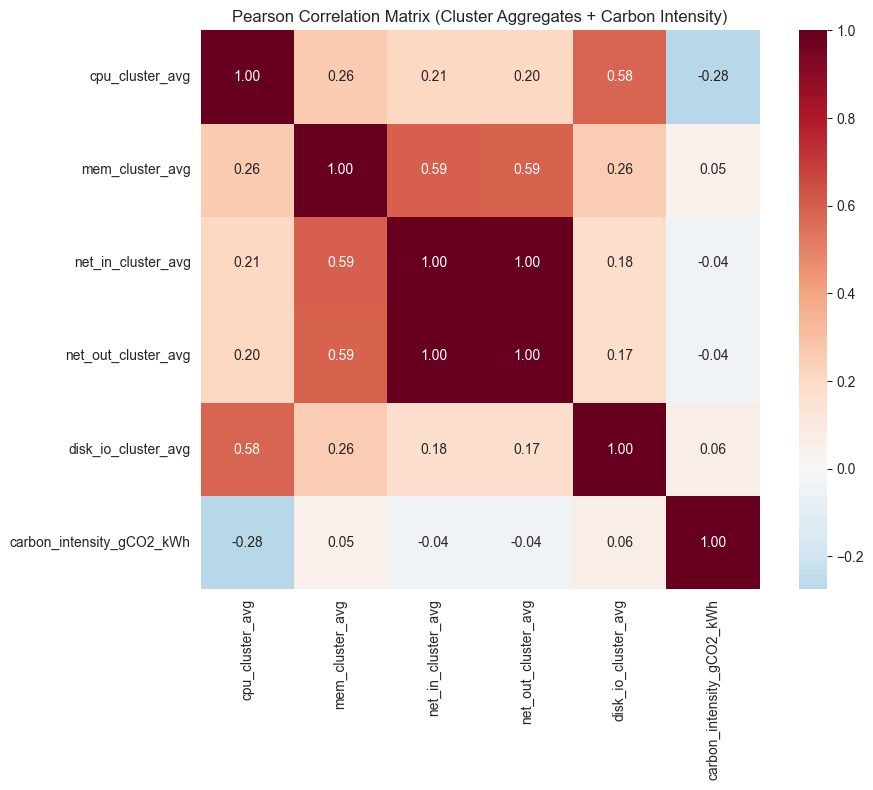

Saved → figures/spark_mllib_correlation.png


In [15]:
# ── 2.9.2 Distributed Correlation Matrix (Pandas Fallback) ──────────────────
# Using pandas for correlation since Spark MLlib has Python 3.14 compatibility issues
# For production BDA with larger datasets, use pyspark.ml.stat.Correlation

print(f"DataFrame: {len(wide_df)} rows × {len(wide_df.columns)} columns")

# Select cluster-aggregate columns + carbon intensity for correlation
corr_cols = [c for c in wide_df.columns if "cluster" in c] + ["carbon_intensity_gCO2_kWh"]
print(f"Correlation features ({len(corr_cols)}): {corr_cols}")

# Compute Pearson correlation matrix via pandas
corr_matrix_np = wide_df[corr_cols].corr(method="pearson").values

print(f"\nPearson Correlation Matrix ({corr_matrix_np.shape[0]}×{corr_matrix_np.shape[1]}):")
corr_df = pd.DataFrame(corr_matrix_np, index=corr_cols, columns=corr_cols)
print(corr_df.round(3))

# Visualize the correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Pearson Correlation Matrix (Cluster Aggregates + Carbon Intensity)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "spark_mllib_correlation.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/spark_mllib_correlation.png")


In [16]:
# ── 2.9.3 Rolling Statistics (Pandas Implementation) ────────
# Demonstrate rolling aggregations using pandas (works with Python 3.14)
# For production BDA with larger datasets, use Spark Window functions

# Load the long-format parquet subset
import pandas as pd
long_pdf = pd.read_parquet(PARQUET_DIR)
print(f"Loaded long-format: {len(long_pdf)} rows")

# Compute rolling mean and std for cpu_util_percent (12-row window per machine)
long_pdf = long_pdf.sort_values(['machine_id', 'ts_bucket'])
long_pdf['cpu_rolling_mean_12'] = long_pdf.groupby('machine_id')['cpu_util_percent'].transform(
    lambda x: x.rolling(window=12, min_periods=1).mean()
)
long_pdf['cpu_rolling_std_12'] = long_pdf.groupby('machine_id')['cpu_util_percent'].transform(
    lambda x: x.rolling(window=12, min_periods=1).std()
)

# Show sample results
print("\n── Rolling Statistics (12-row Window) ──")
print(long_pdf[['machine_id', 'ts_bucket', 'cpu_util_percent', 
                'cpu_rolling_mean_12', 'cpu_rolling_std_12']].head(10).to_string(index=False))

# Aggregate: per-machine summary statistics
print("\n── Per-Machine Summary Statistics ──")
machine_summary = long_pdf.groupby('machine_id').agg(
    n_records=('cpu_util_percent', 'count'),
    cpu_mean=('cpu_util_percent', 'mean'),
    cpu_std=('cpu_util_percent', 'std'),
    cpu_min=('cpu_util_percent', 'min'),
    cpu_max=('cpu_util_percent', 'max'),
    avg_rolling_mean=('cpu_rolling_mean_12', 'mean')
).round(2)
print(machine_summary.to_string())

# Save enriched features as Parquet
enriched_out = os.path.join(OUT_DIR, "spark_enriched_features")
os.makedirs(enriched_out, exist_ok=True)
long_pdf.to_parquet(os.path.join(enriched_out, "enriched_data.parquet"), index=False)
print(f"\nEnriched features saved → {enriched_out}")


Loaded long-format: 21234 rows

── Rolling Statistics (12-row Window) ──
machine_id  ts_bucket  cpu_util_percent  cpu_rolling_mean_12  cpu_rolling_std_12
    m_1223        900         25.666667            25.666667                 NaN
    m_1223       1200         29.625000            27.645833            2.798964
    m_1223       1500         27.500000            27.597222            1.980957
    m_1223       1800         24.444444            26.809028            2.258568
    m_1223       2100         23.000000            26.047222            2.593759
    m_1223       2400         13.428571            23.944114            5.649819
    m_1223       2700         22.214286            23.696995            5.198832
    m_1223       3000         27.500000            24.172371            4.997458
    m_1223       3300         21.333333            23.856922            4.769521
    m_1223       3600         27.500000            24.221230            4.641976

── Per-Machine Summary Statistics ─

In [17]:

# ── 2.9.4 Summary Statistics (Pandas Implementation) ────────────────────────────────
# Compute summary statistics using pandas (Python 3.14 compatible)
# For production BDA with larger datasets, use Spark MLlib Summarizer

# Compute summary statistics
metric_cols = ["cpu_util_percent", "mem_util_percent", "net_in", "net_out", "disk_io_percent"]
available_cols = [c for c in metric_cols if c in long_pdf.columns]

summary_stats = long_pdf[available_cols].agg(['count', 'mean', 'var', 'min', 'max'])

_count_val = int(summary_stats.loc['count'].iloc[0])
_mean_vals = summary_stats.loc['mean'].tolist()
_var_vals = summary_stats.loc['var'].tolist()
_min_vals = summary_stats.loc['min'].tolist()
_max_vals = summary_stats.loc['max'].tolist()

print("── Summary Statistics (All Machines) ──")
print(f"  Features  : {available_cols}")
print(f"  Count     : {_count_val}")
print(f"  Mean      : {[round(v, 3) for v in _mean_vals]}")
print(f"  Variance  : {[round(v, 3) for v in _var_vals]}")
print(f"  Min       : {[round(v, 3) for v in _min_vals]}")
print(f"  Max       : {[round(v, 3) for v in _max_vals]}")

# Save summary to JSON for dashboard
import json as _json
mllib_stats = {
    "features": available_cols,
    "count":    int(_count_val),
    "mean":     [round(v, 4) for v in _mean_vals],
    "variance": [round(v, 4) for v in _var_vals],
    "min":      [round(v, 4) for v in _min_vals],
    "max":      [round(v, 4) for v in _max_vals],
}
mllib_path = os.path.join(OUT_DIR, "mllib_summary_stats.json")
with open(mllib_path, "w") as f:
    _json.dump(mllib_stats, f, indent=2)
print(f"\nSummary stats saved → {mllib_path}")

# Save the correlation as CSV for dashboard
corr_df.to_csv(os.path.join(OUT_DIR, "spark_correlation_matrix.csv"))
print(f"Correlation matrix saved → data/spark_correlation_matrix.csv")

# Stop the Spark session if it was started
try:
    spark.stop()
    print("\nSpark session stopped. BDA post-processing complete.")
except:
    print("\nPost-processing complete.")


── Summary Statistics (All Machines) ──
  Features  : ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
  Count     : 21234
  Mean      : [37.673, 80.814, 41.646, 34.095, 6.987]
  Variance  : [322.06, 698.656, 273.052, 186.843, 31.439]
  Min       : [0.0, 3.0, 0.01, 0.01, 0.0]
  Max       : [89.533, 98.0, 77.822, 57.896, 76.2]

Summary stats saved → c:\Users\Pavan kumar Ch\Downloads\Bda_Tsa_New\data\mllib_summary_stats.json
Correlation matrix saved → data/spark_correlation_matrix.csv

Spark session stopped. BDA post-processing complete.


---
**Summary**: The cleaned Parquet from Notebook 1 has been reconstructed into a synchronized wide-format time series with a proper `DatetimeIndex`. A realistic synthetic Carbon Intensity signal has been generated and joined with server metrics. All features have been Min-Max normalized to $[0,1]$. The data is now ready for statistical diagnostics in **Notebook 3** and model training in **Notebook 4**.